# 05 – Resultados Comparativos: MLP vs CNN vs ResNet

Este notebook agrega os resultados dos três modelos (MLP, CNN, ResNet)  
e produz tabelas e gráficos comparativos para o relatório.

> **Como funcionar:** Corre primeiro os notebooks `02_mlp.ipynb`, `03_cnn.ipynb` e `04_resnet.ipynb`  
> para que os CSVs em `../results/` sejam gerados. Depois corre este notebook.

## 1. Importações e Configuração

In [8]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:.4f}'.format)

RESULTS_DIR = '../results'

## 2. Carregar Resultados

In [9]:
# Carregar todos os CSVs disponíveis em ../results/
csv_files = glob.glob(os.path.join(RESULTS_DIR, '*_results.csv'))

if not csv_files:
    print('Nenhum ficheiro CSV encontrado em', RESULTS_DIR)
    print('Corre primeiro os notebooks 02_mlp.ipynb, 03_cnn.ipynb e 04_resnet.ipynb.')
else:
    dfs = []
    for f in sorted(csv_files):
        df = pd.read_csv(f)
        dfs.append(df)
        print(f'Carregado: {os.path.basename(f)}  ({len(df)} experimentos)')

    df_all = pd.concat(dfs, ignore_index=True)
    print(f'\nTotal: {len(df_all)} experimentos de {df_all["Model"].nunique()} modelo(s).')
    df_all

Carregado: cnn_results.csv  (8 experimentos)
Carregado: mlp_results.csv  (8 experimentos)

Total: 16 experimentos de 2 modelo(s).


## 3. Melhor Experimento por Modelo

In [10]:
# Melhor resultado (Val Accuracy) por modelo
df_best = (
    df_all
    .sort_values('Val Accuracy', ascending=False)
    .groupby('Model', sort=False)
    .first()
    .reset_index()
    [['Model', 'Experiment', 'Val Accuracy', 'Macro F1', 'Top-5 Acc']]
)
df_best

,Model,Experiment,Val Accuracy,Macro F1,Top-5 Acc
0,CNN,CNN-A_CrossEntropy_RMSprop,0.7885,0.7867,0.9500
1,MLP,MLP-A_CrossEntropy_Adam,0.4625,0.4613,0.7337


## 4. Tabela Completa de Todos os Experimentos

In [11]:
df_sorted = df_all.sort_values(['Model', 'Val Accuracy'], ascending=[True, False])
df_sorted

,Model,Experiment,Val Accuracy,Macro F1,Top-5 Acc
0,CNN,CNN-A_CrossEntropy_RMSprop,0.7885,0.7867,0.9500
1,CNN,CNN-A_CrossEntropy_Adam,0.7577,0.7582,0.9490
2,CNN,CNN-A_MultiMargin_RMSprop,0.7096,0.7040,0.9260
3,CNN,CNN-A_MultiMargin_Adam,0.7077,0.7070,0.9308
4,CNN,CNN-B_CrossEntropy_Adam,0.6750,0.6708,0.9279
5,CNN,CNN-B_MultiMargin_Adam,0.6529,0.6434,0.9240
6,CNN,CNN-B_CrossEntropy_RMSprop,0.5721,0.5571,0.8750
7,CNN,CNN-B_MultiMargin_RMSprop,0.5587,0.5371,0.8692
8,MLP,MLP-A_CrossEntropy_Adam,0.4625,0.4613,0.7337
9,MLP,MLP-A_CrossEntropy_RMSprop,0.4548,0.4526,0.7346


## 5. Gráfico Comparativo (Melhor por Modelo)

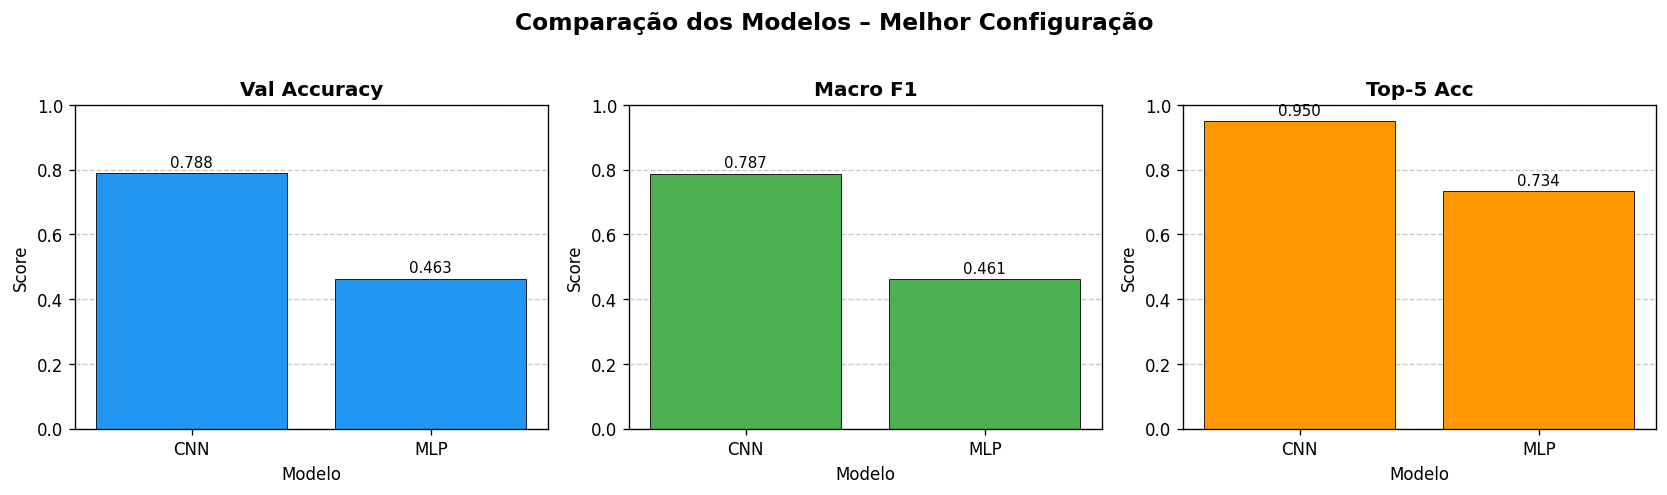

Gráfico guardado em ../results/comparison_bar.png


In [12]:
metrics = ['Val Accuracy', 'Macro F1', 'Top-5 Acc']
colors  = ['#2196F3', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(df_best['Model'], df_best[metric], color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    ax.set_xlabel('Modelo')
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    # Anotar valores
    for bar in ax.patches:
        ax.annotate(
            f'{bar.get_height():.3f}',
            (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01),
            ha='center', va='bottom', fontsize=9
        )

fig.suptitle('Comparação dos Modelos – Melhor Configuração', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_bar.png'), bbox_inches='tight')
plt.show()
print('Gráfico guardado em', os.path.join(RESULTS_DIR, 'comparison_bar.png'))

## 6. Val Accuracy – Todos os Experimentos

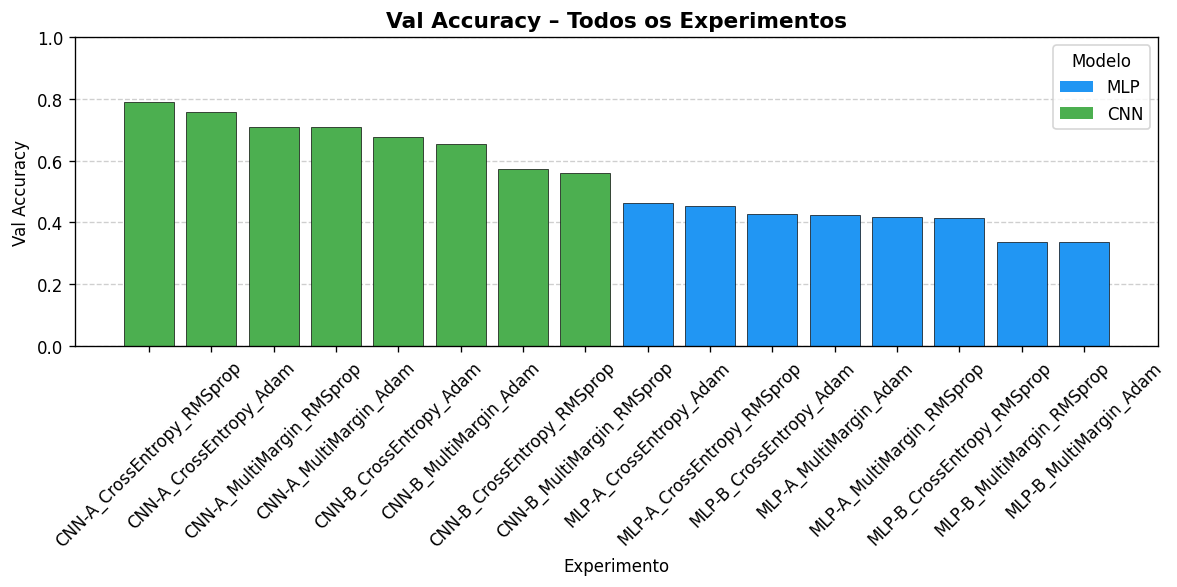

Gráfico guardado em ../results/all_experiments_accuracy.png


In [13]:
color_map = {'MLP': '#2196F3', 'CNN': '#4CAF50', 'ResNet': '#FF9800'}

fig, ax = plt.subplots(figsize=(max(10, len(df_all) * 0.6), 5))

bar_colors = [color_map.get(m, '#888') for m in df_all['Model']]
bars = ax.bar(df_all['Experiment'], df_all['Val Accuracy'], color=bar_colors, edgecolor='black', linewidth=0.4)

ax.set_title('Val Accuracy – Todos os Experimentos', fontsize=13, fontweight='bold')
ax.set_ylabel('Val Accuracy')
ax.set_ylim(0, 1)
ax.set_xlabel('Experimento')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

# Legenda por modelo
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=m) for m, c in color_map.items() if m in df_all['Model'].values]
ax.legend(handles=legend_elements, title='Modelo')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'all_experiments_accuracy.png'), bbox_inches='tight')
plt.show()
print('Gráfico guardado em', os.path.join(RESULTS_DIR, 'all_experiments_accuracy.png'))